In [13]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def topk_per_d_per_method(data, param_cols, k=3):
    """
    Return up to the top-k configs per (d, method), ranked by avg_rmse.
    `data` can be a CSV path or a pandas DataFrame.
    `param_cols` MUST include 'd' and 'method' plus any hyperparams.
    """
    # Load
    df = pd.read_csv(data) if isinstance(data, str) else data.copy()

    # Safety checks
    required = set(param_cols) | {'seed', 'val_rmse', 'val_mae'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in data: {sorted(missing)}")

    # Aggregate across seeds for each unique config
    agg = (df.groupby(param_cols, as_index=False)
             .agg(avg_rmse=('rmse','mean'),
                  avg_mae=('mae','mean'),
                  n_seeds=('seed','nunique')))

    # Rank within (d, method) and take top-k (handles <k gracefully)
    out = (agg.sort_values(['d', 'target_instances', 'method','avg_rmse'])
              .groupby(['d', 'target_instances', 'method'], group_keys=False)
              .apply(lambda g: g.nsmallest(k, 'avg_rmse'))
              .reset_index(drop=True))

    return out


In [20]:
top3_tradaboost = topk_per_d_per_method(
    f'results/tradaboost_ablation_friedman.csv',
    param_cols=['d','target_instances' ,'method' ,'n_estimators', 'lr', 'tree_size', 'val_rmse','val_mae','rmse','mae'],
    k=1
)



print("Top 3 per d — plain XGBoost:\n")
top3_tradaboost


Top 3 per d — plain XGBoost:



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_12656\31719306.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(k, 'avg_rmse'))


,d,target_instances,method,n_estimators,lr,tree_size,val_rmse,val_mae,rmse,mae,avg_rmse,avg_mae,n_seeds
0,1,100,TradaBoostR2,10,0.1,2,0.918689,0.747856,0.92294,0.744365,0.92294,0.744365,1


In [42]:
print("\nTop 3 per d — XGBoost Naive Transfer:\n")
top3_xgb_naive


Top 3 per d — XGBoost Naive Transfer:



,d,method,v,target_tree_size,avg_rmse,avg_mae,n_seeds
0,2,xgboost_naive_transfer,0.15,2,1.124712,0.884298,5
1,4,xgboost_naive_transfer,0.05,3,1.627984,1.277783,5
2,6,xgboost_naive_transfer,0.10,4,2.084752,1.642319,5


In [43]:
top3_mlp = topk_per_d_per_method(
    f'results/MLP_ablation_{train_size}.csv',
    param_cols=['d', 'method', 'base_lr', 'fine_tuning_lr', 'dropout_rate', 'batch_norm'],
    k=1
)
print("Top 3 per d — MLP finetuning:\n")
top3_mlp

Top 3 per d — MLP finetuning:



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27544\2828551223.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(k, 'avg_rmse'))


,d,method,base_lr,fine_tuning_lr,dropout_rate,batch_norm,avg_rmse,avg_mae,n_seeds
0,2,MLP,0.0001,0.0001,0.0,False,1.557936,1.234073,5
1,4,MLP,0.0001,0.0001,0.0,False,1.720525,1.373093,5
2,6,MLP,0.0005,0.0001,0.0,False,1.791911,1.445321,5


In [44]:
top3_transfer = topk_per_d_per_method(
    f'results/LSTransferTreeBoost_ablation_{train_size}.csv',
    param_cols=['d', 'method', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'],
    k=1
)
print("Top 3 per d — TransferTreeBoost:\n")
top3_transfer

Top 3 per d — TransferTreeBoost:



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27544\2828551223.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(k, 'avg_rmse'))


,d,method,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds
0,2,LSTransferTreeBoost,0.05,2,1,0.01,0.9,1.546547,1.228191,5
1,4,LSTransferTreeBoost,0.10,2,1,0.01,0.9,1.606551,1.278412,5
2,6,LSTransferTreeBoost,0.10,2,1,0.05,0.5,1.639586,1.298222,5


In [45]:
df = pd.concat((top3_xgb_plain[['d','method', 'avg_rmse', 'avg_mae']], top3_xgb_naive[['d','method', 'avg_rmse', 'avg_mae']]))
df = pd.concat((df, top3_mlp[['d','method', 'avg_rmse', 'avg_mae']]))
df = pd.concat((df, top3_transfer[['d','method', 'avg_rmse', 'avg_mae']]))

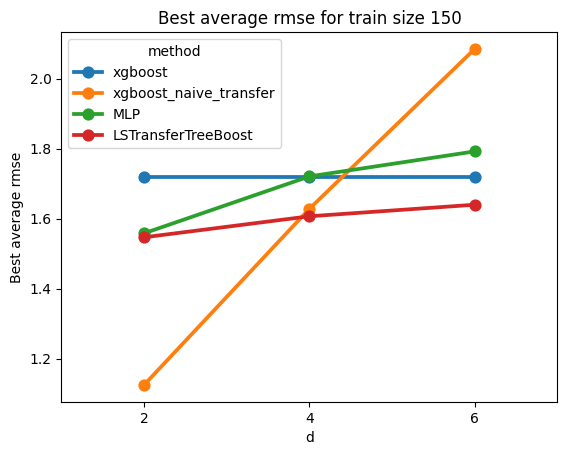

In [46]:
sns.pointplot(data=df, x='d', y='avg_rmse', hue = 'method')
plt.ylabel('Best average rmse')
plt.title('Best average rmse for train size 150')
plt.savefig('friedman.png')